In [8]:
import os
import numpy as np
import sys
from pathlib import Path
from src.prometheus_io import prom_query_range, prom_query_instant, test_connection 
import src.prometheus_io as pio
from datetime import datetime, timezone, timedelta
import matplotlib.pyplot as plt
import pandas as pd
import re

In [9]:
df = pd.read_csv('../exports/intensive_search_monolith.csv')
df

,timestamp,cpu_by_svc__series_0 {'container_label_com_docker_swarm_task_name': 'chat-monolith_app.1.rk4r4tkpriiythzc366emkcm0'},cpu_by_svc__series_1 {'container_label_com_docker_swarm_task_name': 'chat-monolith_cadvisor.2psgdvtnhtcce9zjn6nhcv2x8.z53pmtqvw5id3nbj94gpcjewf'},cpu_by_svc__series_2 {'container_label_com_docker_swarm_task_name': 'chat-monolith_cadvisor.gkxfmk0f14ry4f8cex3726nm9.bkk68nbjzxg7duzl1ju3mq06i'},cpu_by_svc__series_3 {'container_label_com_docker_swarm_task_name': 'chat-monolith_cadvisor.m7evt2fhzisw4dshpe9gae22s.zbgxvr191djp5wljhkldn5yoh'},cpu_by_svc__series_4 {'container_label_com_docker_swarm_task_name': 'chat-monolith_cadvisor.r0dh5upwj4tebg66ket20fv8l.y5jyanb664op1f42gt3o917bn'},cpu_by_svc__series_5 {'container_label_com_docker_swarm_task_name': 'chat-monolith_gateway.1.y9a6zbrg8atzn4e9e8990bab9'},cpu_by_svc__series_6 {'container_label_com_docker_swarm_task_name': 'chat-monolith_node-exporter.2psgdvtnhtcce9zjn6nhcv2x8.rl3nborf1ggokqzslit017bcz'},cpu_by_svc__series_7 {'container_label_com_docker_swarm_task_name': 'chat-monolith_node-exporter.gkxfmk0f14ry4f8cex3726nm9.on7adg3enw4pu8pma3whllq39'},cpu_by_svc__series_8 {'container_label_com_docker_swarm_task_name': 'chat-monolith_node-exporter.m7evt2fhzisw4dshpe9gae22s.lmw4h5fqwe0p5m4deu6irve96'},...,mem_by_svc__series_6 {'container_label_com_docker_swarm_task_name': 'chat-monolith_node-exporter.2psgdvtnhtcce9zjn6nhcv2x8.rl3nborf1ggokqzslit017bcz'},mem_by_svc__series_7 {'container_label_com_docker_swarm_task_name': 'chat-monolith_node-exporter.gkxfmk0f14ry4f8cex3726nm9.on7adg3enw4pu8pma3whllq39'},mem_by_svc__series_8 {'container_label_com_docker_swarm_task_name': 'chat-monolith_node-exporter.m7evt2fhzisw4dshpe9gae22s.lmw4h5fqwe0p5m4deu6irve96'},mem_by_svc__series_9 {'container_label_com_docker_swarm_task_name': 'chat-monolith_node-exporter.r0dh5upwj4tebg66ket20fv8l.sxnemoufl7pik0rc7vfxitmca'},mem_by_svc__series_10 {'container_label_com_docker_swarm_task_name': 'chat-monolith_postgres-exporter.1.iy4p833rp3n2kv9ltlayly2ry'},mem_by_svc__series_11 {'container_label_com_docker_swarm_task_name': 'chat-monolith_postgres.1.ty3yp6bs10dn5ga5bw6aiy19c'},mem_by_svc__series_12 {'container_label_com_docker_swarm_task_name': 'chat-monolith_prometheus.1.aetyqqm8imztbejw93rn2o9sr'},k6_users__series_0 {},http_rt_latency__series_0 {},"pg_database_size_chat_monolith__pg_database_size_bytes {'datname': 'chat_monolith', 'instance': '10.0.1.15:9187', 'job': 'chat-monolith-postgres'}"
0,2026-05-06 08:45:00.752000093+00:00,0.321444,0.027890,0.022425,0.032879,0.033159,0.010867,0.002326,0.002457,0.003434,...,8331264.0,7999488.0,8364032.0,8642560.0,8749056.0,92319744.0,57151488.0,1.0,0.088732,47150771.0
1,2026-05-06 08:45:05.752000093+00:00,0.314213,0.027890,0.022425,0.033417,0.033159,0.010867,0.002326,0.002457,0.003245,...,8331264.0,7999488.0,8368128.0,8642560.0,8749056.0,92119040.0,57151488.0,1.0,0.087364,47150771.0
2,2026-05-06 08:45:10.752000093+00:00,0.314213,0.027698,0.021320,0.033417,0.031906,0.010805,0.003370,0.002365,0.003245,...,8429568.0,8003584.0,8368128.0,8269824.0,8097792.0,92119040.0,57864192.0,1.0,0.087277,47150771.0
3,2026-05-06 08:45:15.752000093+00:00,0.287444,0.027698,0.021320,0.032513,0.031906,0.010805,0.003594,0.002365,0.003301,...,8429568.0,8003584.0,8376320.0,8269824.0,8097792.0,92086272.0,57864192.0,1.0,0.086496,47150771.0
4,2026-05-06 08:45:20.752000093+00:00,0.287444,0.029023,0.021895,0.032513,0.033365,0.011051,0.003503,0.002539,0.003301,...,8310784.0,8028160.0,8376320.0,8269824.0,8536064.0,92086272.0,58466304.0,1.0,0.086359,47150771.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
476,2026-05-06 09:24:40.752000093+00:00,0.009446,0.028720,0.018732,0.035601,0.034841,0.000055,0.003217,0.002039,0.003451,...,8519680.0,8728576.0,8810496.0,8749056.0,7901184.0,101715968.0,76267520.0,2.0,13.801775,47691443.0
477,2026-05-06 09:24:45.752000093+00:00,0.009425,0.028720,0.018732,0.036574,0.034841,0.000055,0.003217,0.001806,0.003507

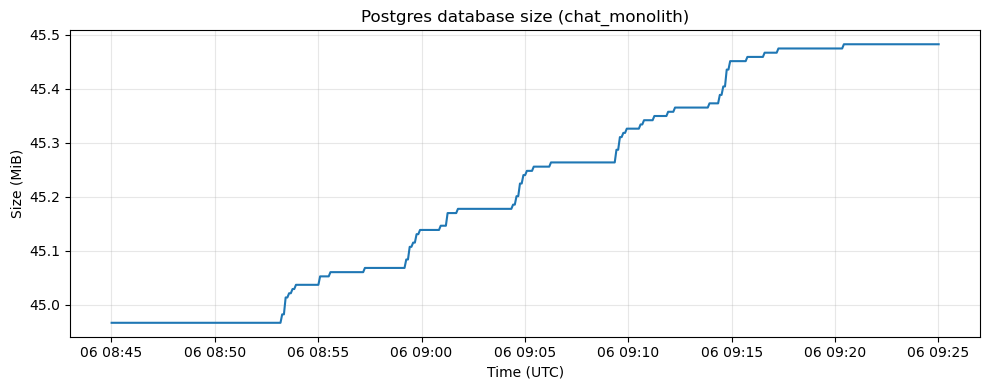

In [10]:
df_plot = df.copy()
df_plot["timestamp"] = pd.to_datetime(df_plot["timestamp"], utc=True)
df_plot = df_plot.set_index("timestamp").sort_index()

pg_col = next((c for c in df_plot.columns if c.startswith("pg_database_size_chat_monolith__")), None)
if pg_col is None:
    raise ValueError("No pg_database_size_chat_monolith column found in CSV")

pg_size_mib = df_plot[pg_col] / (1024 * 1024)

plt.figure(figsize=(10, 4))
plt.plot(pg_size_mib.index, pg_size_mib.values, color="tab:blue")
plt.title("Postgres database size (chat_monolith)")
plt.ylabel("Size (MiB)")
plt.xlabel("Time (UTC)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
